# <p style="text-align: center; color: #2E86C1; font-family: 'Segoe UI', Arial; font-weight: bold; font-size: 32px; margin-bottom: 0px;">📊 WEB TRAFFIC DATA ANALYTICS REPORT</p>
### <p style="text-align: center; color: #3498DB; font-family: 'Segoe UI', Arial; margin-top: 5px;">Week 9: Python for Visualization & Reporting</p>

---

<div style="background-color: #EBF5FB; padding: 20px; border-radius: 10px; border-left: 8px solid #2E86C1;">

### 👥 Project Team: Data Drifters
* 👤 **Thato Msina**
* 👤 **Fikile Noyila**
* 👤 **Lesedi Mphachake**
* 👤 **Jereshan Sinan**
* 👤 **Kaylene Martins**

</div>

---

### 📖 1. Project Overview
This report documents our analytical journey into the **WebTraffic Dataset**. Our goal is to transform raw web traffic data into meaningful visual stories and automated reports. Using **Python**, we will generate traffic trend plots to understand user behavior, page performance, and source effectiveness. Finally, we will automate the generation of this analysis into easily distributable PDF and HTML formats.

### 🛠️ Technology Stack
* **Language:** Python 3 (Data Analysis & Scripting)
* **Library:** Pandas (Data Manipulation)
* **Library:** Matplotlib, Seaborn & Plotly (Visualization & Trend Plotting)
* **Output:** Jupyter Notebook, HTML, and PDF (Automated Reporting)

---

### 📑 Table of Contents
| Section | Description |
| :--- | :--- |
| [🚀 1. Data Loading & Inspection](#data-loading) | Importing the WebTraffic dataset and exploring its structure. |
| [📊 2. Traffic Trend Visualizations](#visualizations) | Generating static and interactive plots (Matplotlib, Seaborn, Plotly) to analyze visits, bounce rates, and traffic sources. |
| [⚙️ 3. Automating Reports](#automating-reports) | Exporting the completed analysis and visuals into HTML and PDF formats for stakeholder review. |

---

<a id="setup"></a>
## 🚀 1. Project Introduction & Setup
*Objective: We begin by preparing our workspace and importing the tools needed to organize, analyze, and report on the web traffic data.*

In [1]:
# Import necessary tools for data manipulation, visualization, and reporting
%pip install fpdf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from fpdf import FPDF
from IPython.display import Javascript, display, FileLink
import os

# Set a nice visual style for all our charts
sns.set_theme(style="whitegrid")

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=6d19efaeb90f9dffebc8fd1c8f9f3be4252c11d1213f0e51a83196e769572bad
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


<a id="data-loading"></a>
## 📥 2. Data Loading & Preparation
*Objective: Import the dataset into our environment and organize it so it's ready for analysis.*

In [2]:
# Load the dataset from the provided file
dataset_link = "https://drive.google.com/uc?export=download&id=1eFe72b6jcms8ES9Z9brGW266s0NIB_1v"
df = pd.read_csv(dataset_link)

# Convert the 'date' column into a proper date format that the computer understands
df['date'] = pd.to_datetime(df['date'])

# Group the data by date to calculate total daily visits across the whole site
daily_data = df.groupby('date').sum(numeric_only=True).reset_index()

# Show the first few rows to confirm it loaded successfully
display(df.head())

,date,page,source,visits,unique_visitors,bounce_rate
0,2025-10-13,Home,Direct,180,150,0.42
1,2025-10-13,Home,Search,220,200,0.35
2,2025-10-13,Home,Social,90,80,0.48
3,2025-10-13,Home,Referral,60,55,0.40
4,2025-10-13,Courses,Direct,95,82,0.38


<a id="data-quality"></a>
## 🔍 3. Data Quality Checks
*Objective: Perform a quick health check on our data to ensure there are no missing values or duplicates before we generate insights.*

In [3]:
# Check for any missing (empty) information in the dataset
missing_data = df.isnull().sum()

# Check for any exact duplicate rows
duplicate_rows = df.duplicated().sum()

# Print out the results in a clean format
print("--- Data Health Check ---")
print(f"Total Missing Values:\n{missing_data}\n")
print(f"Total Duplicate Rows: {duplicate_rows}")
print("Status: Data is clean and ready for analysis! ✅")

--- Data Health Check ---
Total Missing Values:
date               0
page               0
source             0
visits             0
unique_visitors    0
bounce_rate        0
dtype: int64

Total Duplicate Rows: 0
Status: Data is clean and ready for analysis! ✅


<a id="viz-trend"></a>
## 📈 4. Visualization A: Overall Traffic Trend
*Objective: Visualize the daily total website visits to understand the general traffic flow over the tracked period.*

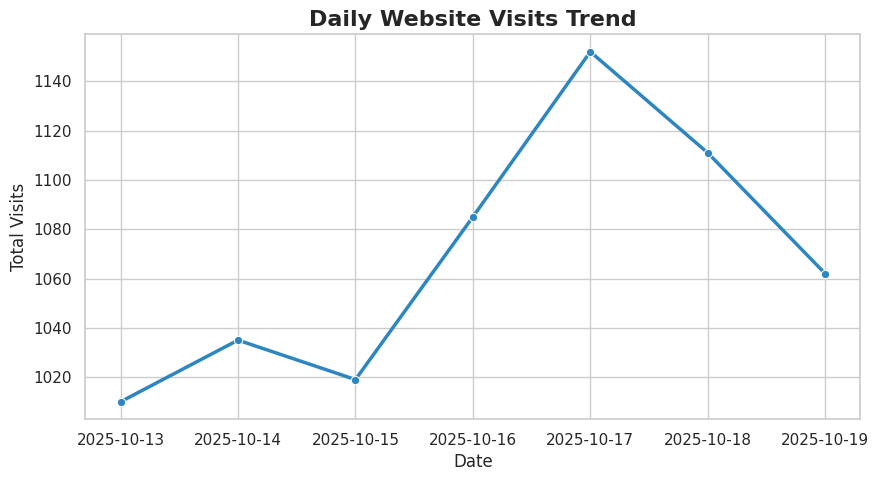

In [22]:
# Create a line chart to show the daily visits trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_data, x='date', y='visits', color='#2E86C1', marker='o', linewidth=2.5)

# Add titles and labels to make the chart easy to read
plt.title('Daily Website Visits Trend', fontsize=16, fontweight='bold')
plt.ylabel('Total Visits')
plt.xlabel('Date')

# Save the picture to use in our PDF report later
plt.savefig('trend_plot.png', dpi=150, bbox_inches='tight')

# Show the chart inside the notebook
plt.show()

<a id="viz-heatmap"></a>
## 🗓️ 5. Visualization B: Traffic Heatmap
*Objective: Identify traffic "hotspots" using a clean, minimalistic grid. Darker squares indicate days with the highest traffic volume for each category.*

In [24]:
from IPython.display import HTML, display
from matplotlib.colors import LinearSegmentedColormap

# 1. Create a Pivot Table (Pages as Rows, Dates as Columns)
# We format the date to 'Oct 13' style so column headers aren't too wide
heatmap_data = pd.pivot_table(
    df,
    values='visits',
    index='page',
    columns=df['date'].dt.strftime('%b %d'),
    aggfunc='sum',
    fill_value=0
)
# Removes the index from the heatmap
heatmap_data.index.name = None

# 2. Define the custom orange colormap (Light Yellow -> Deep Orange/Red)
purple_cmap = LinearSegmentedColormap.from_list(
    "purple",
    ["#eef1f0", "#dadedf", "#c4b1f9", "#835efd", "#233538"]
)

# 3. Apply the custom HTML/CSS styling
styled_table = (
    heatmap_data.style
    .format("") # Format numbers with commas (e.g., 1,000)
    .background_gradient(cmap=purple_cmap, axis=None) # axis=None colors the entire table as a single heatmap
    .set_caption("🔥 Heatmap: Total Daily Visits by Page Category")
    .set_table_styles([
        # Remove pandas default row striping
        {
            "selector": "tbody tr",
            "props": [("background-color", "transparent")]
        },
        # Table spacing
        {
            "selector": "table",
            "props": [
                ("border-collapse", "separate"),
                ("border-spacing", "5px"),
                ("font-family", "'Roboto', Arial, sans-serif"),
                ("background-color", "transparent")
            ]
        },
        # Right-align the row headers (page names) and give them more width
        {
            "selector": "th.row_heading",
            "props": [
                ("text-align", "right"),
                ("min-width", "120px"),   # <--- Increase this to make the first column wider
                ("max-width", "150px"),   # <--- Prevents it from getting too large
                ("padding-right", "15px") # <--- Adds a nice gap between the text and the colored squares
            ]
        },
        # Data cells
        {
            "selector": "td",
            "props": [
                ("border-radius", "6px"),
                ("padding", "10px"),
                ("text-align", "center"),
                ("border", "3px solid transparent"),
                ("background-clip", "padding-box"),
                ("font-family", "'Roboto', Arial, sans-serif"),
                ("min-width", "15px"),
                ("max-width", "15px"),
                ("color", "#333333"),
                ("font-weight", "bold")
            ]
        },
        # Header cells
        {
            "selector": "th",
            "props": [
                ("border-radius", "12px"),
                ("padding", "10px"),
                ("text-align", "center"),
                ("border", "6px solid transparent"),
                ("min-width", "17px"),
                ("max-width", "17px"),
                ("background-clip", "padding-box"),
                ("font-family", "'Roboto', Arial, sans-serif"),
                ("font-weight", "500"),
            ]
        }
    ])
)

# Load Roboto font for the custom styling
display(HTML("""
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@400;500;700&display=swap" rel="stylesheet">
"""))

# Generate a quick Seaborn heatmap image just to save for the PDF
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, cmap=purple_cmap, cbar=False, annot=False, linewidths=2)
plt.title('Traffic Hotspots by Page')
plt.ylabel('') # Hides y-label
plt.savefig('heatmap_plot.png', dpi=150, bbox_inches='tight')
plt.close() # Closes it so it doesn't print a duplicate ugly chart in the notebook

# Display the final styled heatmap table
display(styled_table)

date,Oct 13,Oct 14,Oct 15,Oct 16,Oct 17,Oct 18,Oct 19
Admissions,,,,,,,
Blog,,,,,,,
Contact,,,,,,,
Courses,,,,,,,
Home,,,,,,,


<a id="viz-scenario1"></a>
## 🎯 6. Scenario 1: Marketing Channel Efficiency
*Objective: Analyze the Home page bounce rates to identify which traffic sources bring the most engaged users (lower bounce rate is better).*

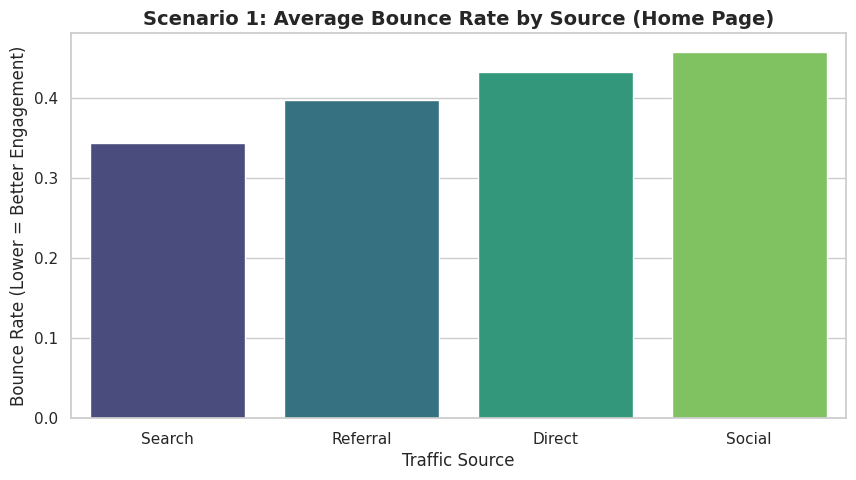

In [19]:
# Filter data to only look at the Home page
home_data = df[df['page'] == 'Home']

# Calculate the average bounce rate for each traffic source
s1_data = home_data.groupby('source')['bounce_rate'].mean().sort_values().reset_index()

# Create a bar chart to compare the sources
plt.figure(figsize=(10, 5))
sns.barplot(data=s1_data, x='source', y='bounce_rate', hue='source', palette='viridis', legend=False)

# Add titles and labels
plt.title('Scenario 1: Average Bounce Rate by Source (Home Page)', fontsize=14, fontweight='bold')
plt.ylabel('Bounce Rate (Lower = Better Engagement)')
plt.xlabel('Traffic Source')

# Save the picture for the PDF report
plt.savefig('s1_plot.png', dpi=150, bbox_inches='tight')

# Show the chart inside the notebook
plt.show()

<a id="viz-scenario2"></a>
## 📚 7. Scenario 2: Content Popularity
*Objective: Compare total visits across different pages to see which content categories attract the most traffic overall.*

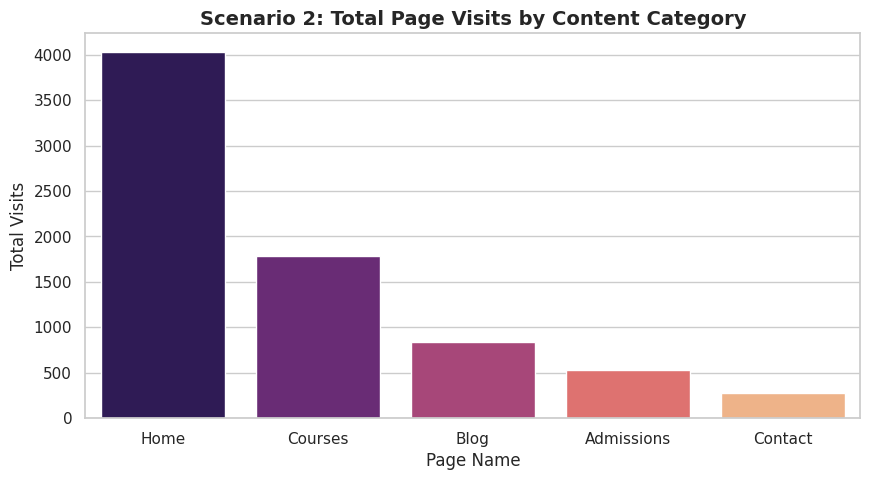

In [20]:
# Calculate total visits for each specific page
s2_data = df.groupby('page')['visits'].sum().sort_values(ascending=False).reset_index()

# Create a bar chart to show page popularity
plt.figure(figsize=(10, 5))
sns.barplot(data=s2_data, x='page', y='visits', hue='page', palette='magma', legend=False)

# Add titles and labels
plt.title('Scenario 2: Total Page Visits by Content Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Visits')
plt.xlabel('Page Name')

# Save the picture for the PDF report
plt.savefig('s2_plot.png', dpi=150, bbox_inches='tight')

# Show the chart inside the notebook
plt.show()

<a id="pdf-report"></a>
## 📄 8. Generate Automated PDF Report
*Objective: Compile our findings, summaries, and saved charts into a professional, automated PDF document for stakeholders.*

In [26]:
import urllib.request
from fpdf import FPDF

# 1. Download a beautiful modern data image for our cover page
cover_img_path = "cover_image.jpg"
image_url = "https://images.unsplash.com/photo-1551288049-bebda4e38f71?q=80&w=800&auto=format&fit=crop"
urllib.request.urlretrieve(image_url, cover_img_path)

# 2. Setup a new PDF document
pdf_file = "Final_WebTraffic_Report.pdf"
pdf = FPDF(orientation='P', unit='mm', format='A4')
pdf.set_auto_page_break(auto=True, margin=15)

# Helper function to easily add a new page with a nice purple border
def add_page_with_border(pdf_obj):
    pdf_obj.add_page()
    # Set border color to match our modern dark purple (#4A235A -> RGB: 74, 35, 90)
    pdf_obj.set_draw_color(74, 35, 90)
    pdf_obj.set_line_width(1) # Thickness of the border
    # Draw rectangle: x=5, y=5, width=200, height=287 (A4 paper is 210x297mm)
    pdf_obj.rect(5, 5, 200, 287)

# --- COVER PAGE ---
add_page_with_border(pdf)
pdf.ln(30) # Add some blank space at the top
pdf.set_font("Arial", 'B', 26)
pdf.cell(0, 15, "WEB TRAFFIC INSIGHTS", ln=True, align='C')
pdf.set_font("Arial", 'I', 14)
pdf.set_text_color(100, 100, 100) # Dark grey text
pdf.cell(0, 10, "Automated Analytics & Performance Report", ln=True, align='C')

pdf.ln(20)
# Add the cover image right in the middle
pdf.image(cover_img_path, x=30, w=150)

pdf.ln(110) # Jump down past the image
pdf.set_text_color(0, 0, 0) # Back to black text
pdf.set_font("Arial", 'B', 12)
pdf.cell(0, 8, "Prepared by: Data Drifters", ln=True, align='C')
pdf.set_font("Arial", '', 11)
pdf.cell(0, 8, "Date: March 2026", ln=True, align='C')

# --- Page 1: General Overview ---
add_page_with_border(pdf)
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "1. Executive Summary: General Traffic Trends", ln=True)

pdf.set_font("Arial", size=11)
pdf.multi_cell(0, 6, "This section visualizes the daily traffic volume during the tracked period. Monitoring these "
                     "trends allows the team to identify peak activity days and evaluate the success of "
                     "recent marketing campaigns or content updates across the entire site.")
pdf.image('trend_plot.png', x=10, y=pdf.get_y() + 5, w=190)

# --- Page 2: Visualization B (Heatmap Image) ---
add_page_with_border(pdf)
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "2. Visualization B: Traffic Hotspots", ln=True)

pdf.set_font("Arial", size=11)
heatmap_desc = (
    "This heatmap provides a visual calendar of our web traffic. The darker squares represent "
    "days with the highest volume of visits for specific content categories. This helps us "
    "quickly spot which days of the week drive the most engagement, allowing us to time "
    "our content releases perfectly."
)
pdf.multi_cell(0, 6, heatmap_desc)
# Using try-except just in case the image wasn't generated in the exact same format
try:
    pdf.image('heatmap_plot.png', x=15, y=pdf.get_y() + 10, w=180)
except RuntimeError:
    pdf.multi_cell(0, 10, "[Heatmap Image missing - Run the Seaborn save code in Cell 9]")

# --- Page 3: Scenario 1 ---
add_page_with_border(pdf)
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "3. Scenario 1: Marketing Channel Efficiency Analysis", ln=True)

pdf.set_font("Arial", size=11)
s1_desc = (
    "This analysis evaluates the quality of traffic based on its source. By comparing the average "
    "bounce rates for the Home page, we can identify which marketing channels - such as Search, "
    "Social, or Referral - are successfully engaging visitors. A higher bounce rate in social "
    "media traffic often indicates that users are leaving the site immediately, suggesting that "
    "our social targeting or the landing page relevance needs improvement. We recommend focusing "
    "more resources on the sources that bring 'sticky' users with lower bounce rates."
)
pdf.multi_cell(0, 6, s1_desc)
pdf.image('s1_plot.png', x=15, y=pdf.get_y() + 5, w=180)

# --- Page 4: Scenario 2 ---
add_page_with_border(pdf)
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "4. Scenario 2: Content Engagement and Page Popularity", ln=True)

pdf.set_font("Arial", size=11)
s2_desc = (
    "This scenario ranks the website's content categories by their total visit volume. By "
    "visualizing total visits for pages like Home, Courses, Blog, and Admissions, we can "
    "identify the primary 'traffic magnets' of the site. This ranking helps the content and "
    "development teams prioritize which pages should receive regular updates, SEO enhancements, "
    "and high-value calls to action."
)
pdf.multi_cell(0, 6, s2_desc)
pdf.image('s2_plot.png', x=15, y=pdf.get_y() + 5, w=180)

# Save the final stylish PDF to our environment
pdf.output(pdf_file)
print("✅ Beautiful PDF Report successfully generated with a custom cover and borders!")

✅ Beautiful PDF Report successfully generated with a custom cover and borders!


<a id="html-download"></a>
## 🌐 9. Interactive HTML & Automated Downloads
*Objective: Create an interactive web-based chart and safely trigger the download of both our final PDF and HTML reports.*

In [31]:
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Javascript, display, FileLink

# 1. Rebuild our visuals as INTERACTIVE Plotly charts (Minimalist white theme)
plotly_template = "plotly_white"

# Chart 1: Trend Line
fig1 = px.line(daily_data, x='date', y='visits', markers=True, template=plotly_template)
fig1.update_traces(line=dict(color='#2E86C1', width=3), marker=dict(size=8))
fig1.update_layout(title_text='Daily Website Visits Trend', title_x=0.5, margin=dict(t=50, l=10, r=10, b=10))

# Chart 2: Scenario 1 (Bounce Rates)
fig2 = px.bar(s1_data, x='source', y='bounce_rate', color='source', template=plotly_template,
              color_discrete_sequence=px.colors.sequential.Viridis)
fig2.update_layout(title_text='Avg Bounce Rate by Source (Home Page)', title_x=0.5, showlegend=False, margin=dict(t=50, l=10, r=10, b=10))

# Chart 3: Scenario 2 (Content Popularity)
fig3 = px.bar(s2_data, x='page', y='visits', color='page', template=plotly_template,
              color_discrete_sequence=px.colors.sequential.Magma)
fig3.update_layout(title_text='Total Visits by Content Category', title_x=0.5, showlegend=False, margin=dict(t=50, l=10, r=10, b=10))

# Chart 4: Heatmap (Using our existing pivot table 'heatmap_data')
fig4 = px.imshow(heatmap_data, color_continuous_scale='Purples', aspect="auto", template=plotly_template)
fig4.update_layout(title_text='Traffic Hotspots by Page & Date', title_x=0.5, margin=dict(t=50, l=10, r=10, b=10))

# 2. Extract the raw HTML divs for each chart (only loading Plotly JS once)
div1 = fig1.to_html(full_html=False, include_plotlyjs='cdn')
div2 = fig2.to_html(full_html=False, include_plotlyjs=False)
div3 = fig3.to_html(full_html=False, include_plotlyjs=False)
div4 = fig4.to_html(full_html=False, include_plotlyjs=False)

# 3. Create a beautiful, custom HTML/CSS Dashboard Template
html_file = "Interactive_Traffic_Dashboard.html"
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Web Traffic Insights Dashboard</title>
    <link href="https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;500;700&display=swap" rel="stylesheet">
    <style>
        body {{
            font-family: 'Roboto', sans-serif;
            background-color: #F4F6F9; /* Very light modern grey/blue */
            margin: 0; padding: 40px 20px; color: #333;
        }}
        .dashboard-header {{ text-align: center; margin-bottom: 40px; }}
        .dashboard-header h1 {{ margin: 0; font-size: 2.8em; color: #2C3E50; font-weight: 700; letter-spacing: -1px; }}
        .dashboard-header p {{ color: #7F8C8D; font-size: 1.2em; font-weight: 300; margin-top: 5px; }}

        /* Modern CSS Grid layout */
        .grid-container {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 25px;
            max-width: 1400px;
            margin: 0 auto;
        }}
        .full-width {{ grid-column: 1 / -1; }} /* Makes a card span both columns */

        /* Clean, floating card styling */
        .card {{
            background: white;
            border-radius: 16px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.05);
            padding: 20px;
            transition: transform 0.2s ease-in-out;
        }}
        .card:hover {{ transform: translateY(-3px); box-shadow: 0 15px 35px rgba(0,0,0,0.08); }}
    </style>
</head>
<body>
    <div class="dashboard-header">
        <h1>🚀 Web Traffic Executive Dashboard</h1>
        <p>Interactive Performance & Engagement Analytics</p>
    </div>

    <div class="grid-container">
        <div class="card full-width">{div1}</div>

        <div class="card">{div2}</div>
        <div class="card">{div3}</div>

        <div class="card full-width">{div4}</div>
    </div>
</body>
</html>
"""

# 4. Save the HTML Dashboard
with open(html_file, "w", encoding="utf-8") as f:
    f.write(html_template)

# --- AUTOMATED DOWNLOAD TRIGGERS ---
print("🎉 Dashboard successfully generated!")
print("Generating download links below...")

# Create manual clickable links for the user
display(FileLink(pdf_file, result_html_prefix="📄 Click here to download PDF: "))
display(FileLink(html_file, result_html_prefix="🌐 Click here to download HTML Dashboard: "))

# Auto-download script
js_code = f"""
setTimeout(function() {{
    var files = ['{pdf_file}', '{html_file}'];
    files.forEach(function(file) {{
        var link = document.createElement('a');
        link.href = file;
        link.download = file;
        document.body.appendChild(link);
        link.click();
        document.body.removeChild(link);
    }});
}}, 1000);
"""
display(Javascript(js_code))

🎉 Dashboard successfully generated!
Generating download links below...


/content/Final_WebTraffic_Report.pdf

/content/Interactive_Traffic_Dashboard.html

<IPython.core.display.Javascript object>